Home Credit Default Risk: EDA & Preprocessing

This notebook performs exploratory data analysis (EDA) and preprocessing on the
**Home Credit Default Risk** dataset (Kaggle public competition).

**Scope:**
1. Load and inspect `application_train.csv`
2. Dataset overview — shape, dtypes, missing values
3. Target variable distribution and class imbalance analysis
4. Missing-value heatmap and column-level missingness
5. Numeric feature distributions (histograms + KDE)
6. Categorical feature distributions (bar charts)
7. DAYS_* column analysis and conversion to year-based features
8. Bivariate analysis — default rate by key categorical features
9. Correlation matrix for top numeric features
10. Boxplots of key numeric features split by TARGET
11. Run `preprocess_homecredit.py` preprocessing and inspect the output
12. Save preprocessed CSV to `outputs/homecredit_preprocessed.csv`

**Prerequisites:**
- Download data first: `python scripts/setup_homecredit_data.py`
- This writes `data/homecredit/application_train.csv`

> **Note:** No model training occurs in this notebook.
> The 4-model pipeline consumes the preprocessed CSV produced in Section 11.

In [4]:
!export KAGGLE_API_TOKEN=KGAT_b416dbbc1e1de8e8e2b445a3753b26d3

In [5]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
print(f'Project root: {PROJECT_ROOT}')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = PROJECT_ROOT / 'data' / 'homecredit'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / 'application_train.csv'
print(f'Training data path: {TRAIN_CSV}')
print(f'Exists: {TRAIN_CSV.exists()}')

Project root: /home/hoitq/Documents/Thesis/credit-scoring-xai
Training data path: /home/hoitq/Documents/Thesis/credit-scoring-xai/data/homecredit/application_train.csv
Exists: True


## 1. Load Data

In [6]:
if not TRAIN_CSV.exists():
    raise FileNotFoundError(
        f'{TRAIN_CSV} not found.\n'
        'Run:  python scripts/setup_homecredit_data.py'
    )

raw = pd.read_csv(TRAIN_CSV, low_memory=False)
print(f'Shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
raw.head(3)

Shape: 307,511 rows × 122 columns


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Dataset Overview

In [7]:
# Data types summary
dtype_summary = raw.dtypes.value_counts().rename('count').rename_axis('dtype').reset_index()
print('Column dtype breakdown:')
print(dtype_summary.to_string(index=False))
print()
print(raw.info(verbose=False, memory_usage='deep'))

Column dtype breakdown:
  dtype  count
float64     65
  int64     41
    str     16

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 505.0 MB
None


In [8]:
# Missing-value summary
miss = (
    raw.isnull().sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda d: d['missing_count'] / len(raw) * 100)
    .query('missing_count > 0')
    .sort_values('missing_pct', ascending=False)
)
print(f'Columns with missing values: {len(miss)} / {raw.shape[1]}')
print(f'Total missing cells: {miss["missing_count"].sum():,}  '
      f'({miss["missing_count"].sum() / raw.size:.1%} of all cells)')
miss.head(20)

Columns with missing values: 67 / 122
Total missing cells: 9,152,465  (24.4% of all cells)


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


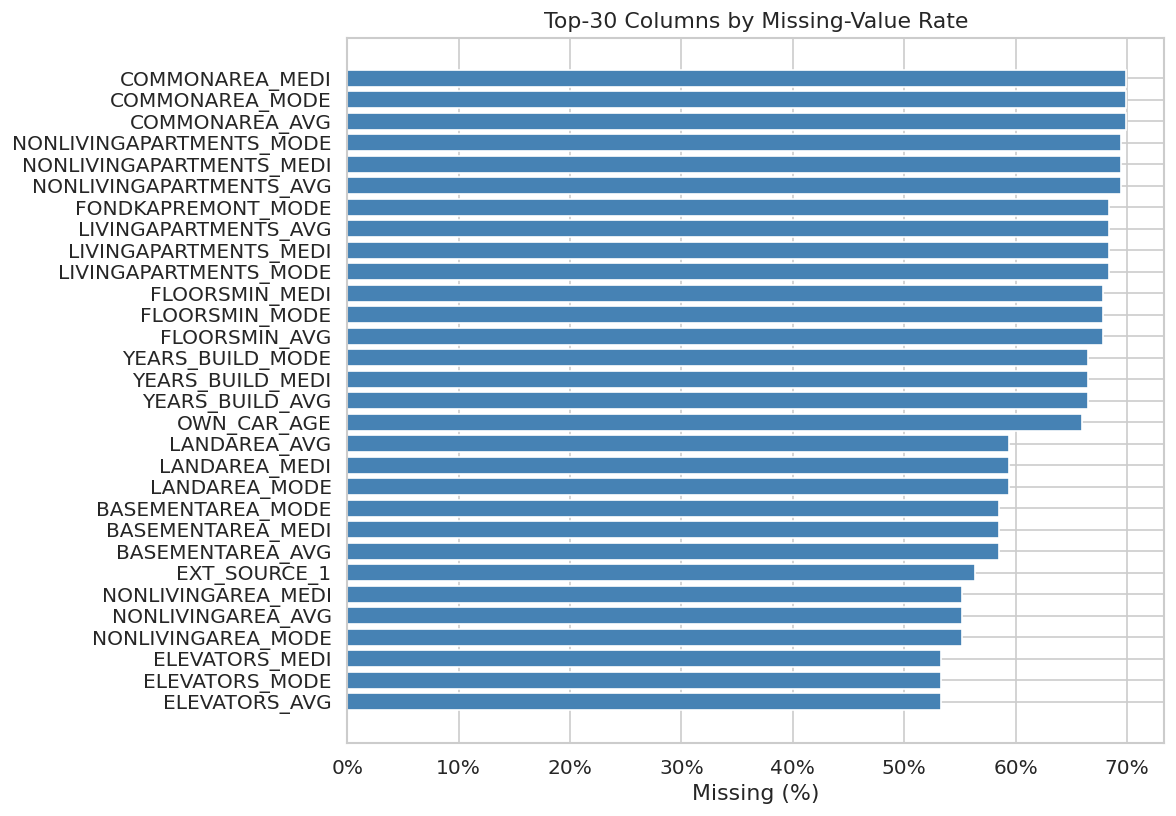

In [9]:
# Top-30 columns by missingness
top30_miss = miss.head(30)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top30_miss.index[::-1], top30_miss['missing_pct'][::-1], color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Top-30 Columns by Missing-Value Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'homecredit_missing_top30.png', bbox_inches='tight')
plt.show()

## 3. Target Variable Distribution

Target distribution:
  Repaid   (0):  282,686  (91.93%)
  Defaulted (1):   24,825  (8.07%)

Default rate: 8.07% → class imbalance ratio ~1:11.4


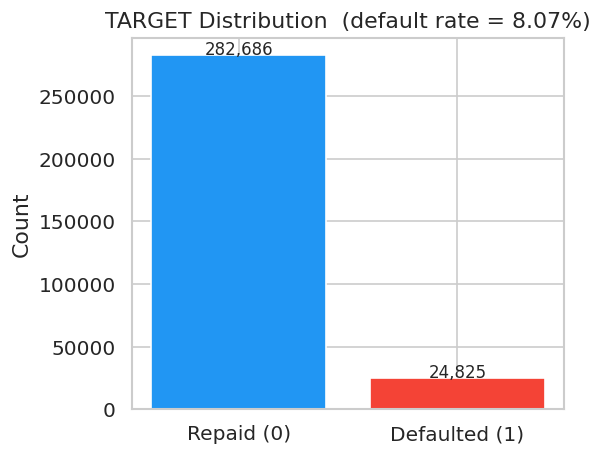

In [10]:
target_counts = raw['TARGET'].value_counts().sort_index()
default_rate = raw['TARGET'].mean()

print(f'Target distribution:')
for label, count in target_counts.items():
    label_str = 'Defaulted (1)' if label == 1 else 'Repaid   (0)'
    print(f'  {label_str}: {count:>8,}  ({count / len(raw):.2%})')
print(f'\nDefault rate: {default_rate:.2%} → class imbalance ratio ~1:{1/default_rate - 1:.1f}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Repaid (0)', 'Defaulted (1)'], target_counts.values,
       color=['#2196F3', '#F44336'], edgecolor='white')
ax.set_ylabel('Count')
ax.set_title(f'TARGET Distribution  (default rate = {default_rate:.2%})')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'homecredit_target_dist.png', bbox_inches='tight')
plt.show()

## 4. DAYS_* Column Analysis

In [11]:
days_cols = [c for c in raw.columns if c.startswith('DAYS_')]
print('DAYS_* columns:', days_cols)

# Convert to positive years for display
days_df = raw[days_cols].copy()
days_df['DAYS_EMPLOYED'] = days_df['DAYS_EMPLOYED'].replace(365243, np.nan)
years_df = (-days_df / 365.25).clip(lower=0)
years_df.columns = [c.replace('DAYS_', '').replace('_', ' ').title() + ' (yrs)' for c in days_cols]
years_df['TARGET'] = raw['TARGET']

print('\nYear-converted DAYS_* summary:')
years_df.drop(columns='TARGET').describe().round(1)

DAYS_* columns: ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']

Year-converted DAYS_* summary:


,Birth (yrs),Employed (yrs),Registration (yrs),Id Publish (yrs),Last Phone Change (yrs)
count,307511.0,252137.0,307511.0,307511.0,307510.0
mean,43.9,6.5,13.7,8.2,2.6
std,11.9,6.4,9.6,4.1,2.3
min,20.5,-0.0,-0.0,0.0,-0.0
25%,34.0,2.1,5.5,4.7,0.8
50%,43.1,4.5,12.3,8.9,2.1
75%,53.9,8.7,20.5,11.8,4.3
max,69.1,49.0,67.5,19.7,11.8


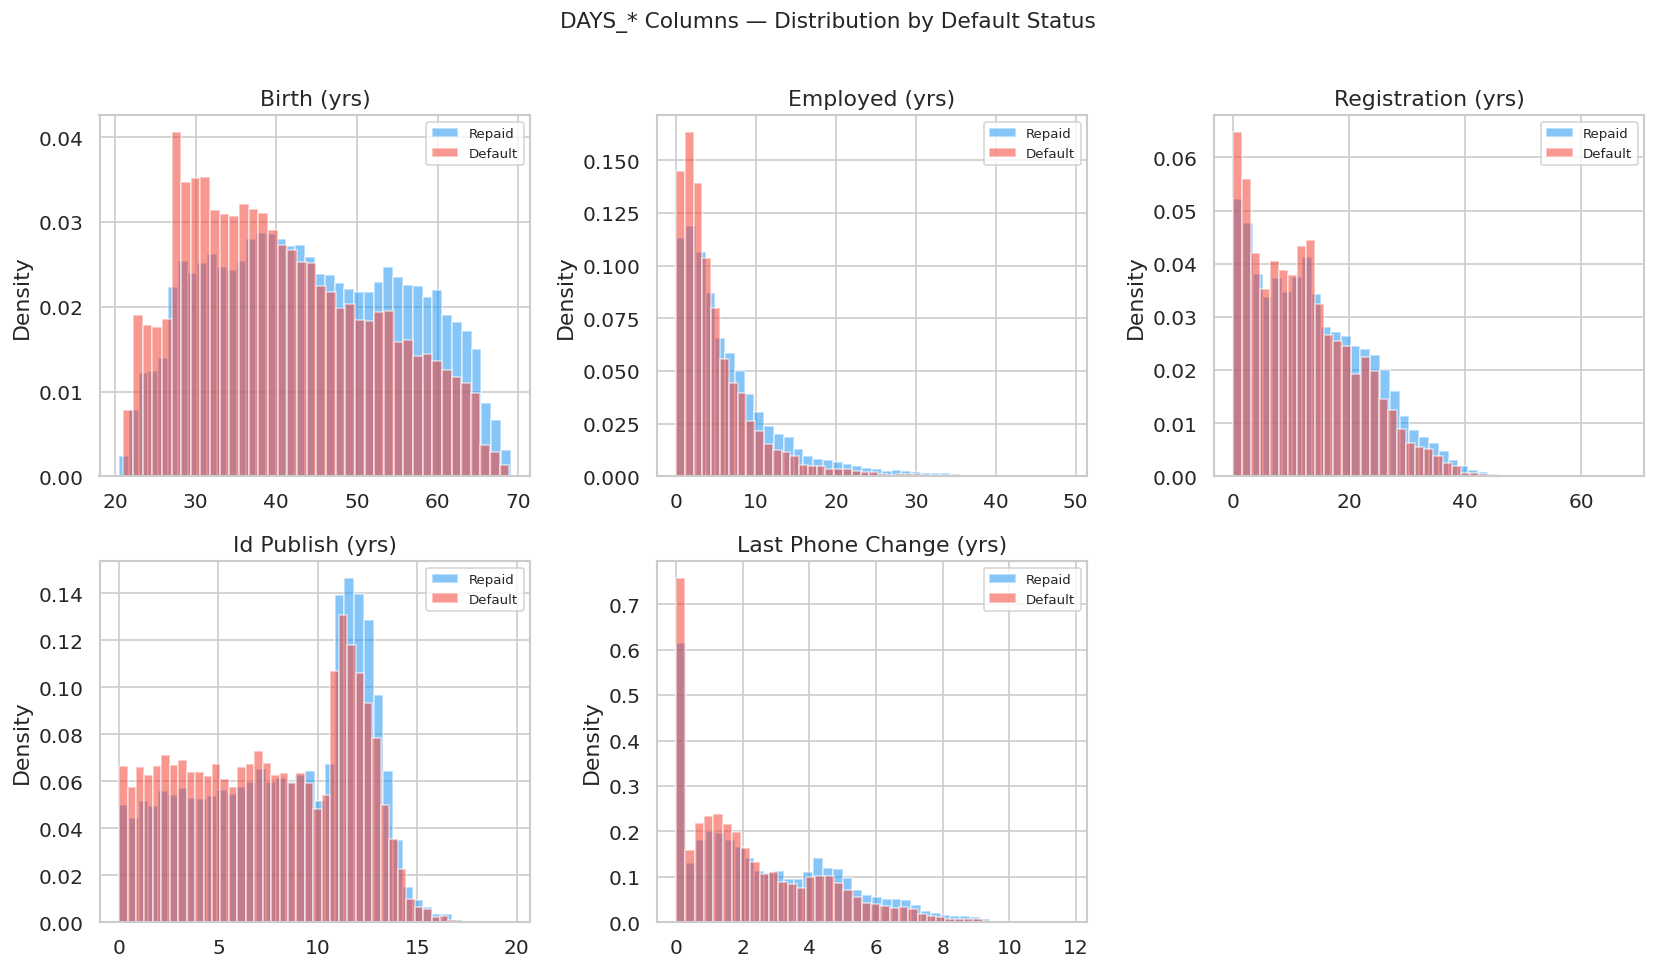

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
year_cols = [c for c in years_df.columns if c != 'TARGET']
for ax, col in zip(axes.flat, year_cols):
    for tgt, label, color in [(0, 'Repaid', '#2196F3'), (1, 'Default', '#F44336')]:
        vals = years_df.loc[years_df['TARGET'] == tgt, col].dropna()
        ax.hist(vals, bins=40, alpha=0.55, label=label, color=color, density=True)
    ax.set_title(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

for ax in axes.flat[len(year_cols):]:
    ax.set_visible(False)

plt.suptitle('DAYS_* Columns — Distribution by Default Status', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'homecredit_days_dist.png', bbox_inches='tight')
plt.show()

## 5. Numeric Feature Distributions

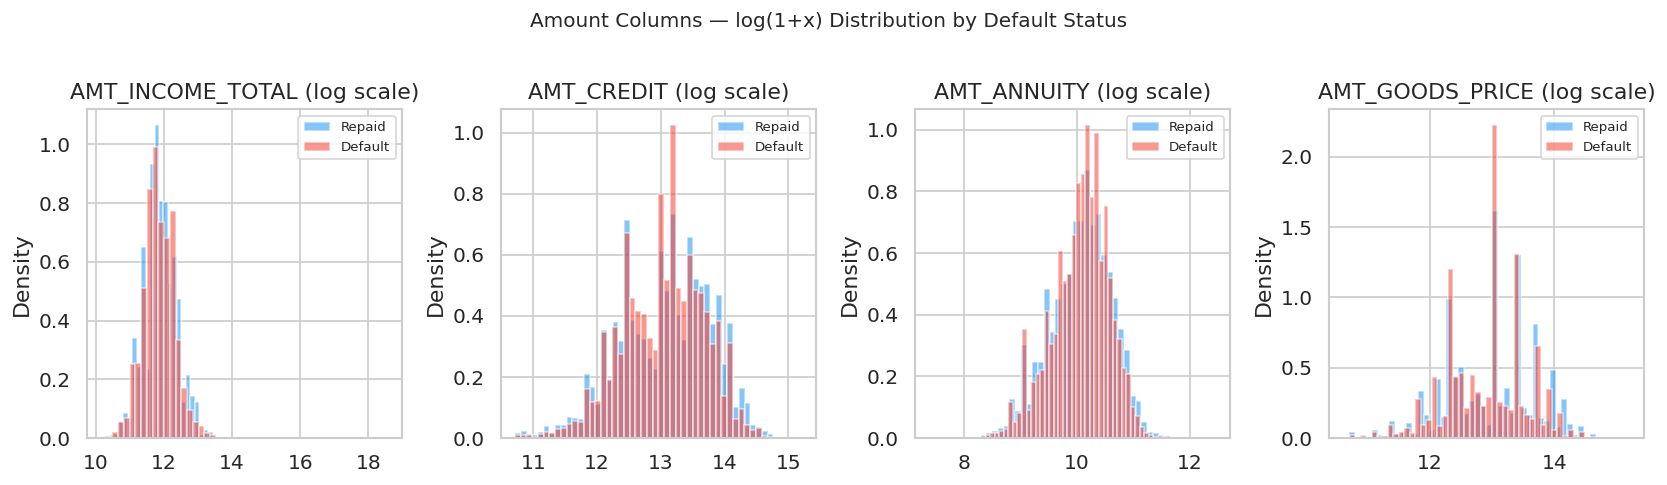

In [13]:
AMT_COLS = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
amt_present = [c for c in AMT_COLS if c in raw.columns]

fig, axes = plt.subplots(1, len(amt_present), figsize=(14, 4))
if len(amt_present) == 1:
    axes = [axes]

for ax, col in zip(axes, amt_present):
    for tgt, label, color in [(0, 'Repaid', '#2196F3'), (1, 'Default', '#F44336')]:
        vals = raw.loc[raw['TARGET'] == tgt, col].dropna()
        ax.hist(np.log1p(vals), bins=50, alpha=0.55, label=label, color=color, density=True)
    ax.set_title(f'{col} (log scale)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Amount Columns — log(1+x) Distribution by Default Status', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'homecredit_amt_dist.png', bbox_inches='tight')
plt.show()

## 6. Categorical Feature Analysis

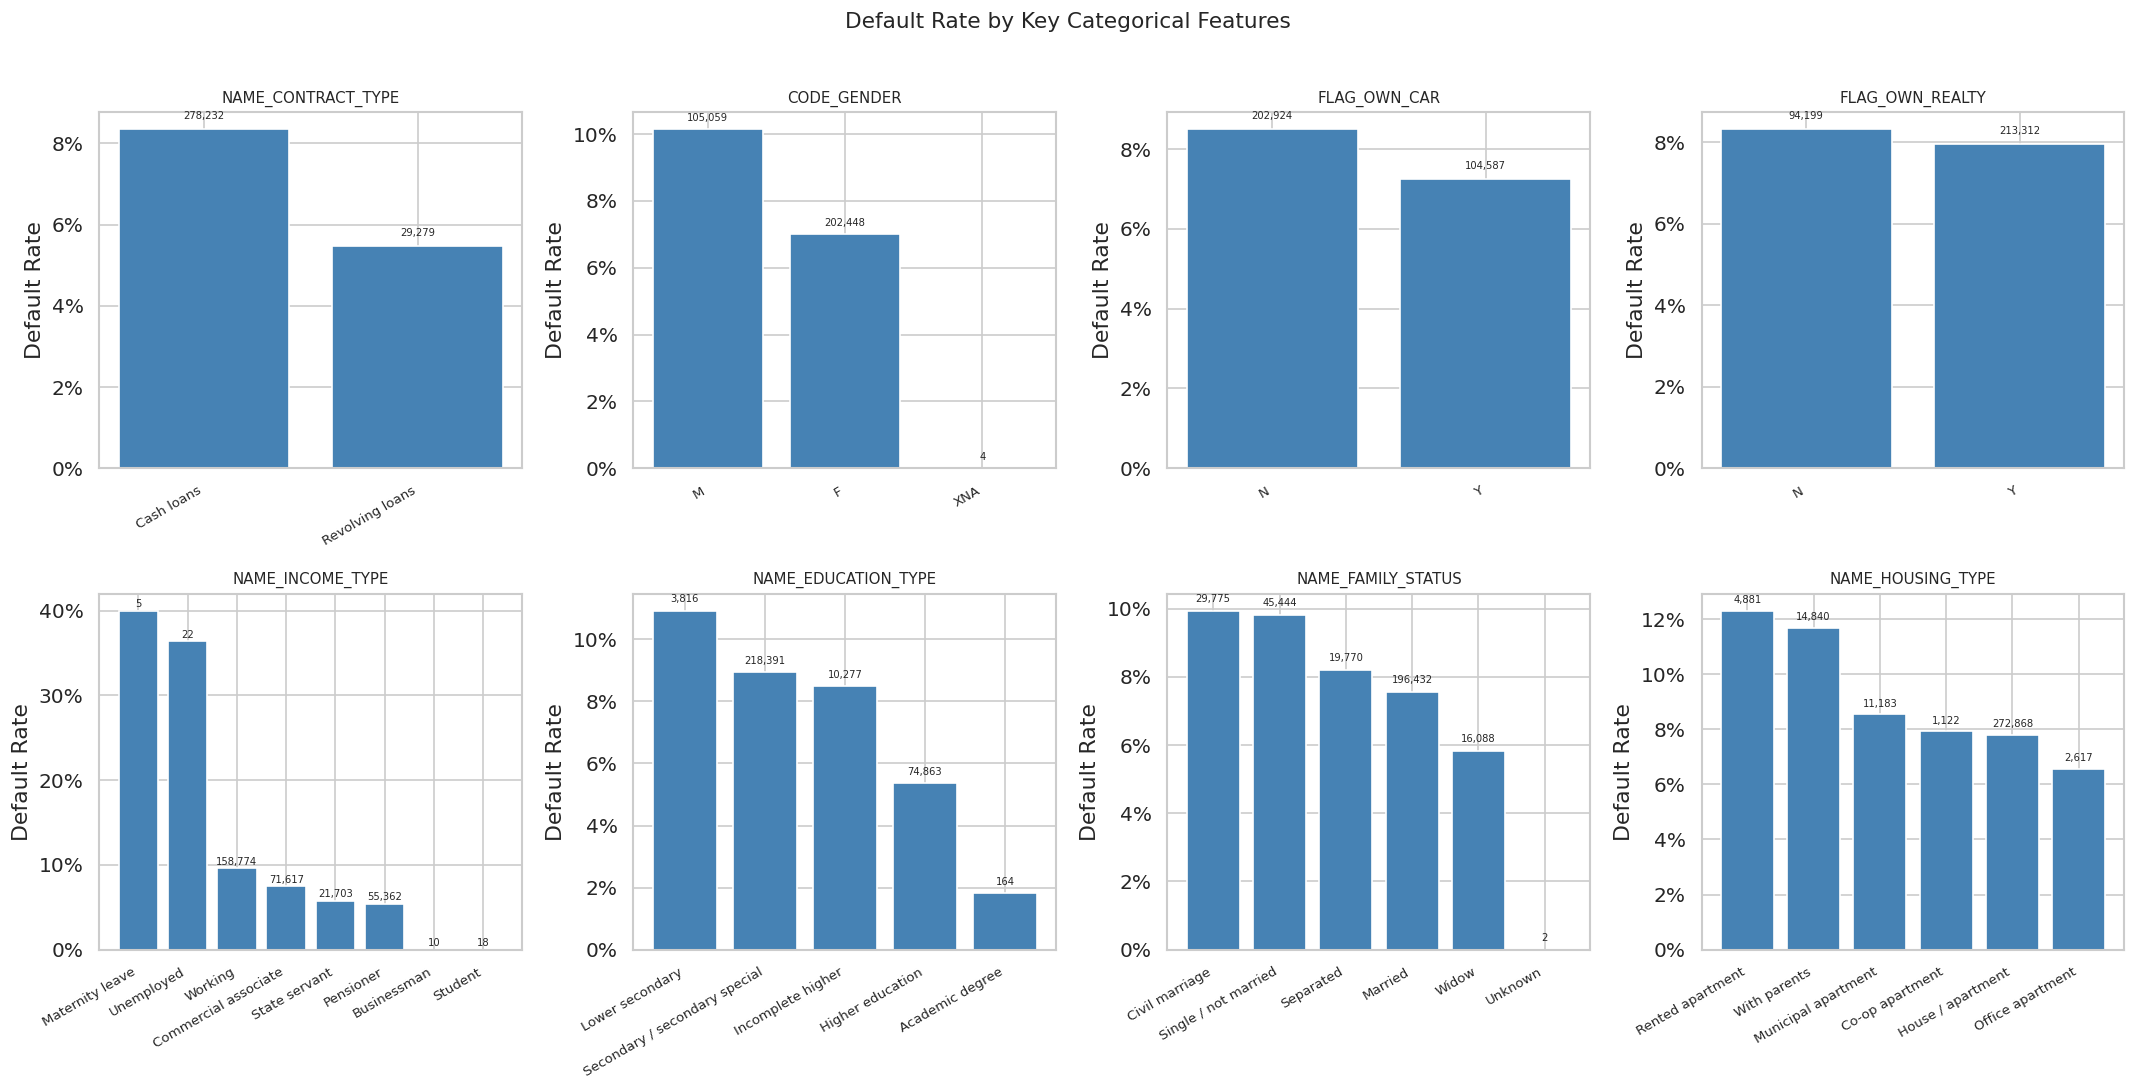

In [14]:
KEY_CAT_COLS = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE'
]
key_cat_present = [c for c in KEY_CAT_COLS if c in raw.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flat, key_cat_present):
    dr = (
        raw.groupby(col, observed=True)['TARGET']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'default_rate', 'count': 'n'})
        .sort_values('default_rate', ascending=False)
    )
    bars = ax.bar(range(len(dr)), dr['default_rate'], color='steelblue')
    ax.set_xticks(range(len(dr)))
    ax.set_xticklabels(dr.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Default Rate')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    for bar, (_, row) in zip(bars, dr.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{row["n"]:,.0f}', ha='center', va='bottom', fontsize=6)

for ax in axes.flat[len(key_cat_present):]:
    ax.set_visible(False)

plt.suptitle('Default Rate by Key Categorical Features', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'homecredit_categorical_default_rate.png', bbox_inches='tight')
plt.show()

## 7. Correlation Matrix (Top Numeric Features)

Top 15 features by |correlation| with TARGET:
EXT_SOURCE_3                   0.179
EXT_SOURCE_2                   0.160
EXT_SOURCE_1                   0.155
DAYS_BIRTH                     0.078
DAYS_EMPLOYED                  0.075
REGION_RATING_CLIENT_W_CITY    0.061
REGION_RATING_CLIENT           0.059
DAYS_LAST_PHONE_CHANGE         0.055
DAYS_ID_PUBLISH                0.051
REG_CITY_NOT_WORK_CITY         0.051
FLAG_EMP_PHONE                 0.046
REG_CITY_NOT_LIVE_CITY         0.044
FLAG_DOCUMENT_3                0.044
FLOORSMAX_AVG                  0.044
FLOORSMAX_MEDI                 0.044
dtype: float64


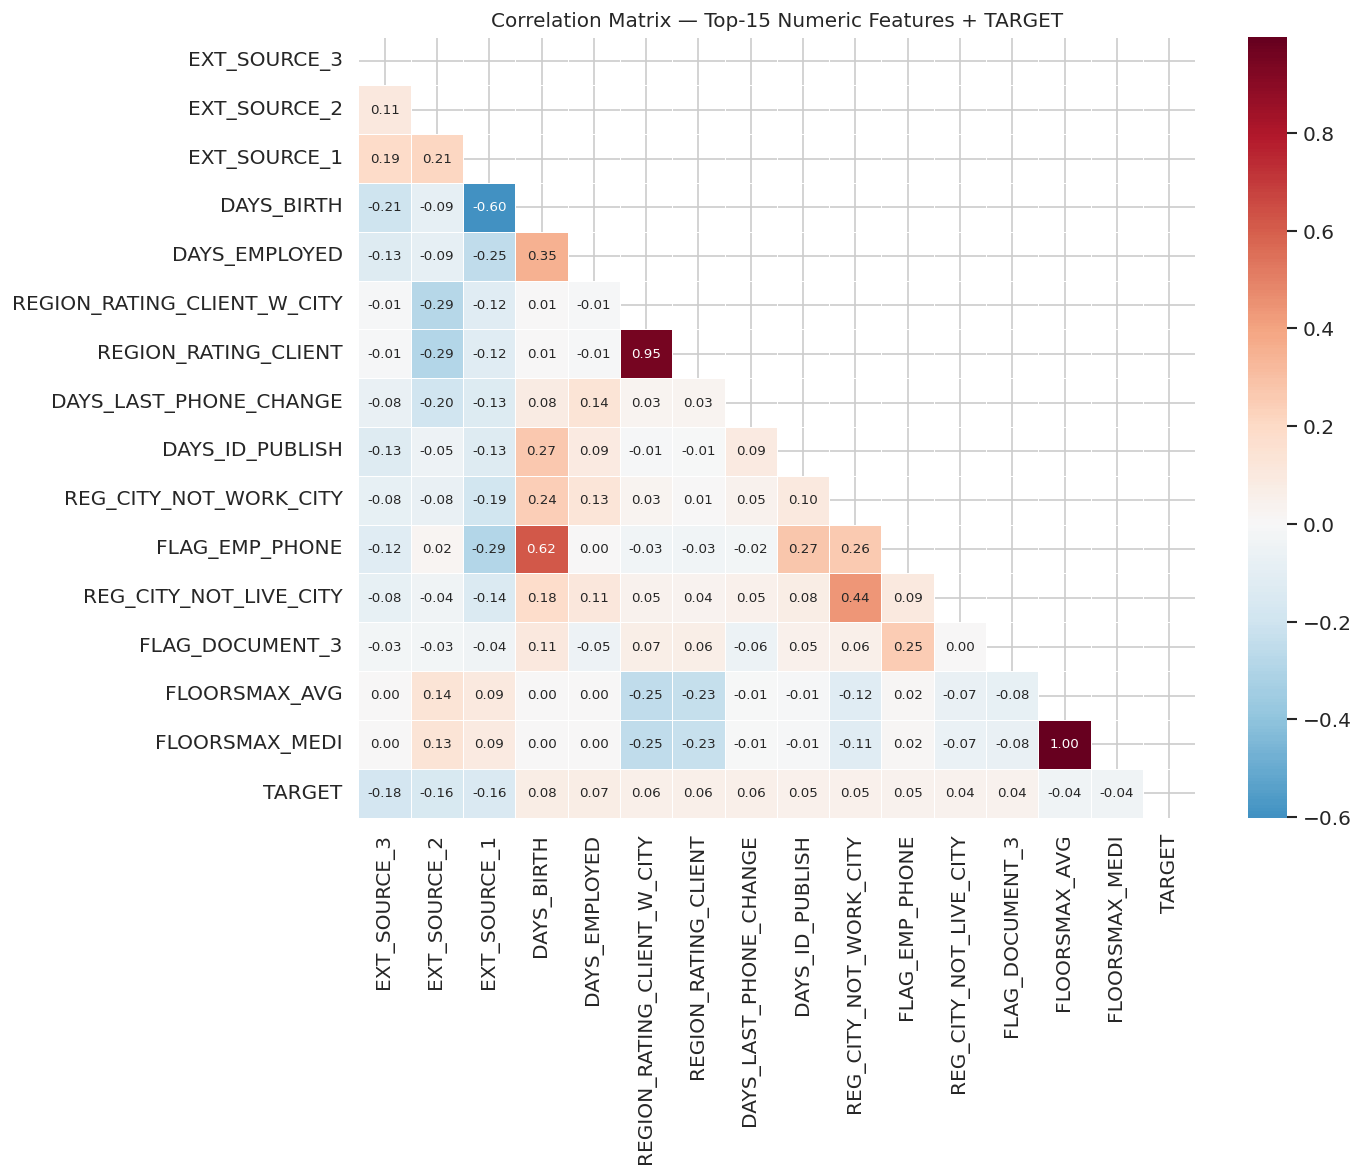

In [15]:
num_raw = raw.select_dtypes(include=[np.number]).copy()

# Replace DAYS_EMPLOYED sentinel before correlation
if 'DAYS_EMPLOYED' in num_raw.columns:
    num_raw['DAYS_EMPLOYED'] = num_raw['DAYS_EMPLOYED'].replace(365243, np.nan)

# Pick top features by absolute correlation with TARGET
corr_with_target = num_raw.corrwith(num_raw['TARGET']).abs().sort_values(ascending=False)
top_features = corr_with_target.drop('TARGET').head(15).index.tolist()
print('Top 15 features by |correlation| with TARGET:')
print(corr_with_target.drop('TARGET').head(15).round(3))

corr_matrix = num_raw[top_features + ['TARGET']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', linewidths=0.4, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix — Top-15 Numeric Features + TARGET', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'homecredit_corr_matrix.png', bbox_inches='tight')
plt.show()

## 8. Boxplots — Key Features by TARGET

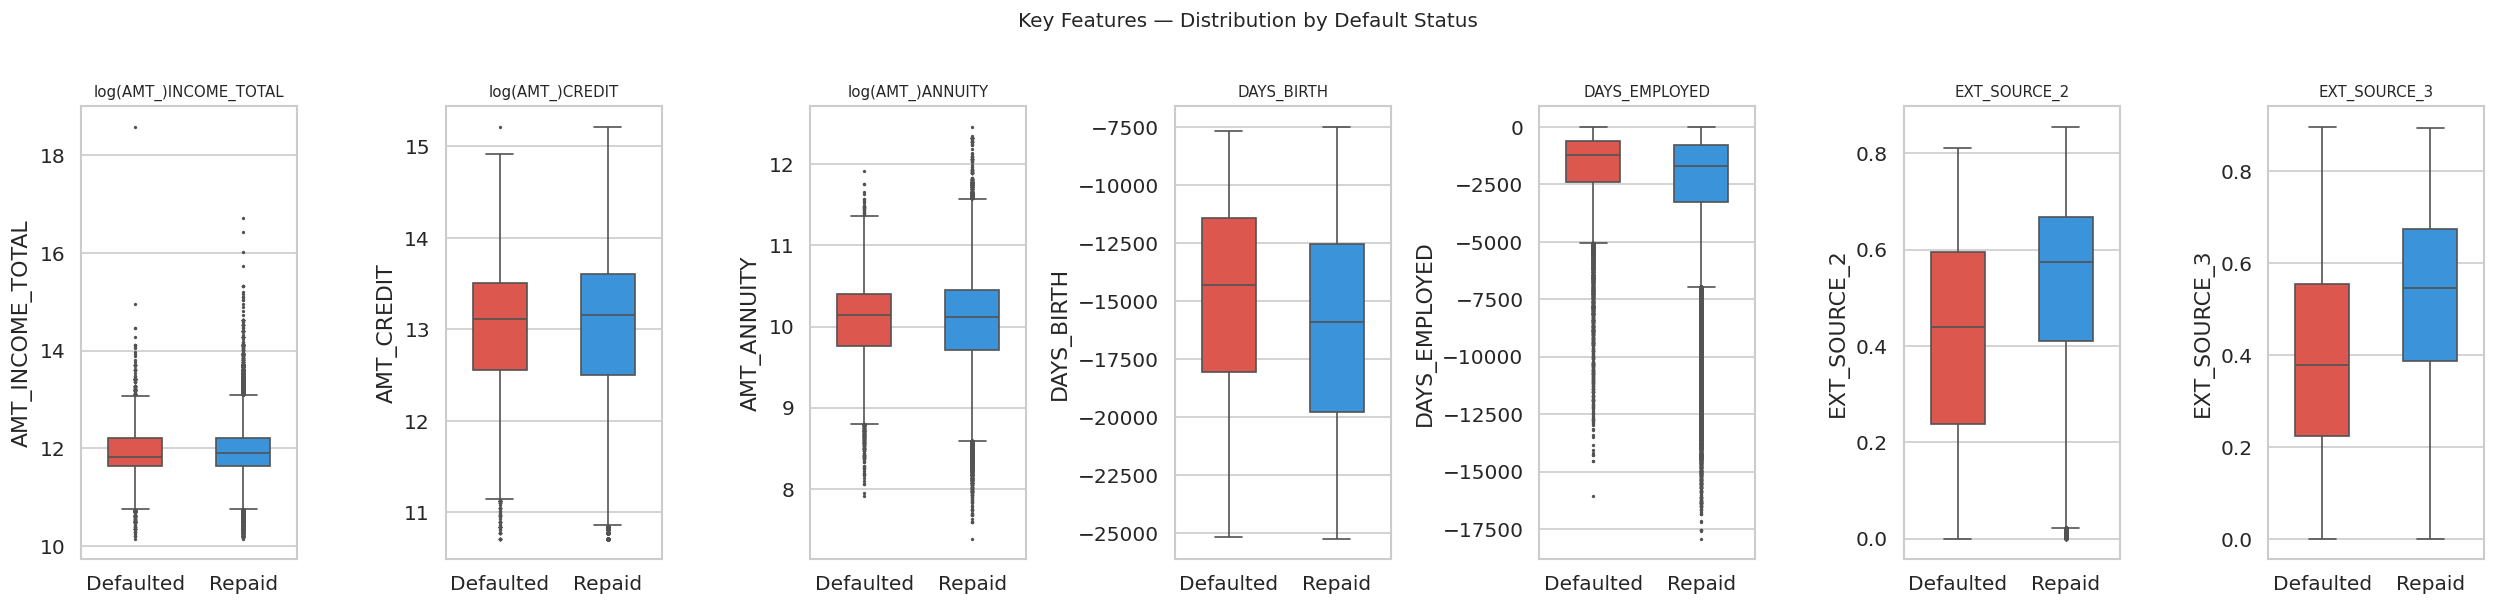

In [16]:
BOXPLOT_COLS = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
                'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
boxplot_present = [c for c in BOXPLOT_COLS if c in raw.columns]

plot_df = raw[boxplot_present + ['TARGET']].copy()
if 'DAYS_EMPLOYED' in plot_df.columns:
    plot_df['DAYS_EMPLOYED'] = plot_df['DAYS_EMPLOYED'].replace(365243, np.nan)
# Use log(1+|x|) for skewed amount columns
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']:
    if col in plot_df.columns:
        plot_df[col] = np.log1p(plot_df[col])

plot_df['TARGET_label'] = plot_df['TARGET'].map({0: 'Repaid', 1: 'Defaulted'})

n_cols = len(boxplot_present)
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 5))
if n_cols == 1:
    axes = [axes]

palette = {'Repaid': '#2196F3', 'Defaulted': '#F44336'}
for ax, col in zip(axes, boxplot_present):
    sns.boxplot(
        data=plot_df, x='TARGET_label', y=col,
        palette=palette, width=0.5, fliersize=1, ax=ax
    )
    display_name = col.replace('AMT_', 'log(AMT_)') if col.startswith('AMT_') else col
    ax.set_title(display_name, fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Key Features — Distribution by Default Status', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'homecredit_boxplots.png', bbox_inches='tight')
plt.show()

## 9. EXT_SOURCE Features (Strong Predictors)

EXT_SOURCE columns: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


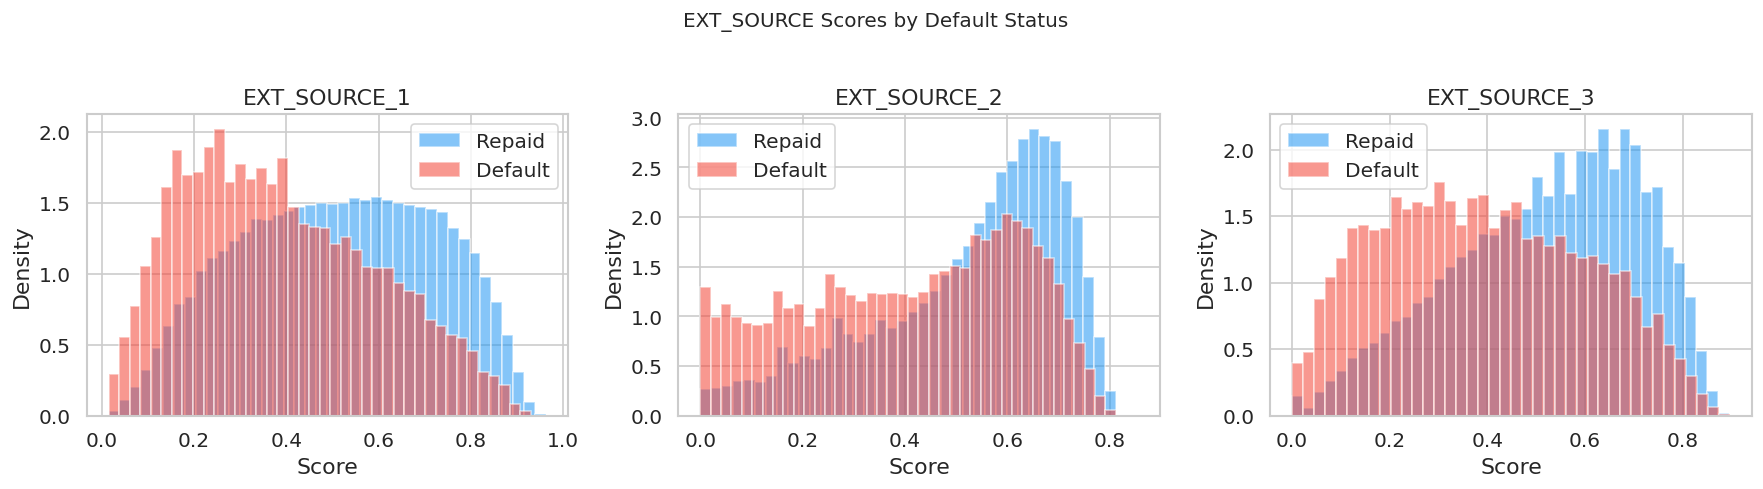

In [17]:
ext_cols = [c for c in raw.columns if c.startswith('EXT_SOURCE')]
print(f'EXT_SOURCE columns: {ext_cols}')

if ext_cols:
    fig, axes = plt.subplots(1, len(ext_cols), figsize=(5 * len(ext_cols), 4))
    if len(ext_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, ext_cols):
        for tgt, label, color in [(0, 'Repaid', '#2196F3'), (1, 'Default', '#F44336')]:
            vals = raw.loc[raw['TARGET'] == tgt, col].dropna()
            ax.hist(vals, bins=40, alpha=0.55, label=label, color=color, density=True)
        ax.set_title(col)
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
        ax.legend()
    plt.suptitle('EXT_SOURCE Scores by Default Status', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'homecredit_ext_source.png', bbox_inches='tight')
    plt.show()

## 10. Preprocessing Pipeline

In [18]:
import subprocess, sys

PREPROCESSED_CSV = OUTPUT_DIR / 'homecredit_preprocessed.csv'
PREPROCESS_SCRIPT = PROJECT_ROOT / 'scripts' / 'preprocess_homecredit.py'

result = subprocess.run(
    [sys.executable, str(PREPROCESS_SCRIPT),
     '--input', str(TRAIN_CSV),
     '--output', str(PREPROCESSED_CSV)],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)
else:
    print('Preprocessing completed successfully.')

Loading /home/hoitq/Documents/Thesis/credit-scoring-xai/data/homecredit/application_train.csv …
  Raw shape: 307,511 rows × 122 columns
  Default rate: 8.07%

Preprocessed shape : 307,511 rows × 230 columns
  Numeric features : 228
  OHE features     : 133
  Missing cells    : 0

Saved preprocessed data → /home/hoitq/Documents/Thesis/credit-scoring-xai/outputs/homecredit_preprocessed.csv

Preprocessing completed successfully.


In [19]:
preprocessed = pd.read_csv(PREPROCESSED_CSV)
print(f'Preprocessed shape: {preprocessed.shape[0]:,} rows × {preprocessed.shape[1]} columns')
print(f'Target distribution:\n{preprocessed["TARGET"].value_counts().sort_index()}')
print(f'\nMissing cells: {preprocessed.isnull().sum().sum()}')
print(f'\nFirst 3 rows:')
preprocessed.head(3)

Preprocessed shape: 307,511 rows × 230 columns
Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Missing cells: 0

First 3 rows:


,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,OWN_CAR_AGE,FLAG_MOBIL,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes,sort_key,TARGET
0,0.0,1.0,0.0,202500.0,406597.5,24700.5,351000.0,0.018801,9.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,100002,1
1,0.0,0.0,0.0,270000.0,1293502.5,35698.5,1129500.0,0.003541,9.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100003,0
2,1.0,1.0,0.0,67500.0,135000.0,6750.0,135000.0,0.010032,26.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,100004,0


## 11. Summary

| Attribute | Value |
|-----------|-------|
| Raw rows | ~307,511 |
| Raw columns | 122 |
| Target (default rate) | ~8.1% |
| Class imbalance ratio | ~1:11 |
| Key predictors | EXT_SOURCE_1/2/3, DAYS_BIRTH, AMT_CREDIT/GOODS_PRICE |
| Missingness | 67 / 122 columns have some missing values |
| Preprocessing | median imputation + OHE + DAYS→years conversion |

**Next step:** Run the 4-model baseline on the preprocessed file:
```bash
python scripts/run_4model_homecredit.py \
    --data-path outputs/homecredit_preprocessed.csv \
    --target-col TARGET \
    --sort-col sort_key
```